In [123]:
# !git clone https://github.com/Kemsekov/kemsekov_torch

In [124]:
import numpy as np
import pandas as pd
import torch

# age, height, weight dataset
data_csv = (pd.read_csv("data.csv"))
data_csv = data_csv.drop(columns=data_csv.columns[:2])

data_mean = data_csv.mean()
data_std = data_csv.std()
normalized_data = (data_csv-data_mean)/data_std
normalized_data=torch.tensor(normalized_data.to_numpy()).float()

data_mean=torch.tensor(data_mean.to_numpy())
data_std=torch.tensor(data_std.to_numpy())

In [125]:
data_csv

,age,weight,height
0,2,13.7,88.6
1,2,13.9,94.2
2,66,79.5,158.3
3,18,66.3,175.7
4,13,45.4,158.4
...,...,...,...
8000,70,49.0,156.5
8001,42,97.4,164.9
8002,41,69.1,162.6
8003,14,111.9,156.6


In [126]:
data = normalized_data
data.shape

torch.Size([8005, 3])

In [127]:
import math
from kemsekov_torch.invertible_nn import SmoothSymmetricSqrt, KFunction
from kemsekov_torch.normalizing_flow import NormalizingFlow
from kemsekov_torch.flow_matching import FlowModel1d
torch.manual_seed(2)

fm = FlowModel1d(
    data.shape[-1],
    hidden_dim=64,
    residual_blocks=3,
    dropout_p=0.0,
    device='cuda'
)
with torch.no_grad():
    print("logprob before train",fm.log_prob(data).mean())
fm.fit(data,batch_size=512,epochs=64,debug=True)
with torch.no_grad():
    print("logprob after train",fm.log_prob(data).mean())

logprob before train tensor(-1.0284)
Epoch 1: best_loss=3.000	best r2=0.128
Epoch 2: best_loss=2.565	best r2=0.331
Epoch 3: best_loss=2.516	best r2=0.353
Epoch 4: best_loss=2.479	best r2=0.373
Epoch 8: best_loss=2.460	best r2=0.380
Epoch 10: best_loss=2.442	best r2=0.383
Epoch 12: best_loss=2.439	best r2=0.383
Epoch 13: best_loss=2.429	best r2=0.392
Epoch 17: best_loss=2.438	best r2=0.396
Epoch 24: best_loss=2.427	best r2=0.403
Epoch 46: best_loss=2.399	best r2=0.408
Epoch 51: best_loss=2.391	best r2=0.409
Last Epoch 63: best_loss=2.382	best_r2=0.411
logprob after train tensor(1.1406)


In [128]:
# fm_reflow.to(fm_reflow.device)
# next(fm_reflow.parameters()).device

In [129]:
from copy import deepcopy
import math

fm_reflow = deepcopy(fm)
torch.manual_seed(0)
fm_reflow.reflow(data,epochs=512)

with torch.no_grad():
    print("logprob after reflow",fm_reflow.log_prob(data).mean())

/home/vlad/Cardio/One-Step-Exact-Likelihood-FlowMatching/kemsekov_torch/common_modules.py:47: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if out.shape!=x.shape:


logprob after reflow tensor(1.1373)


MMD^2 0.0004


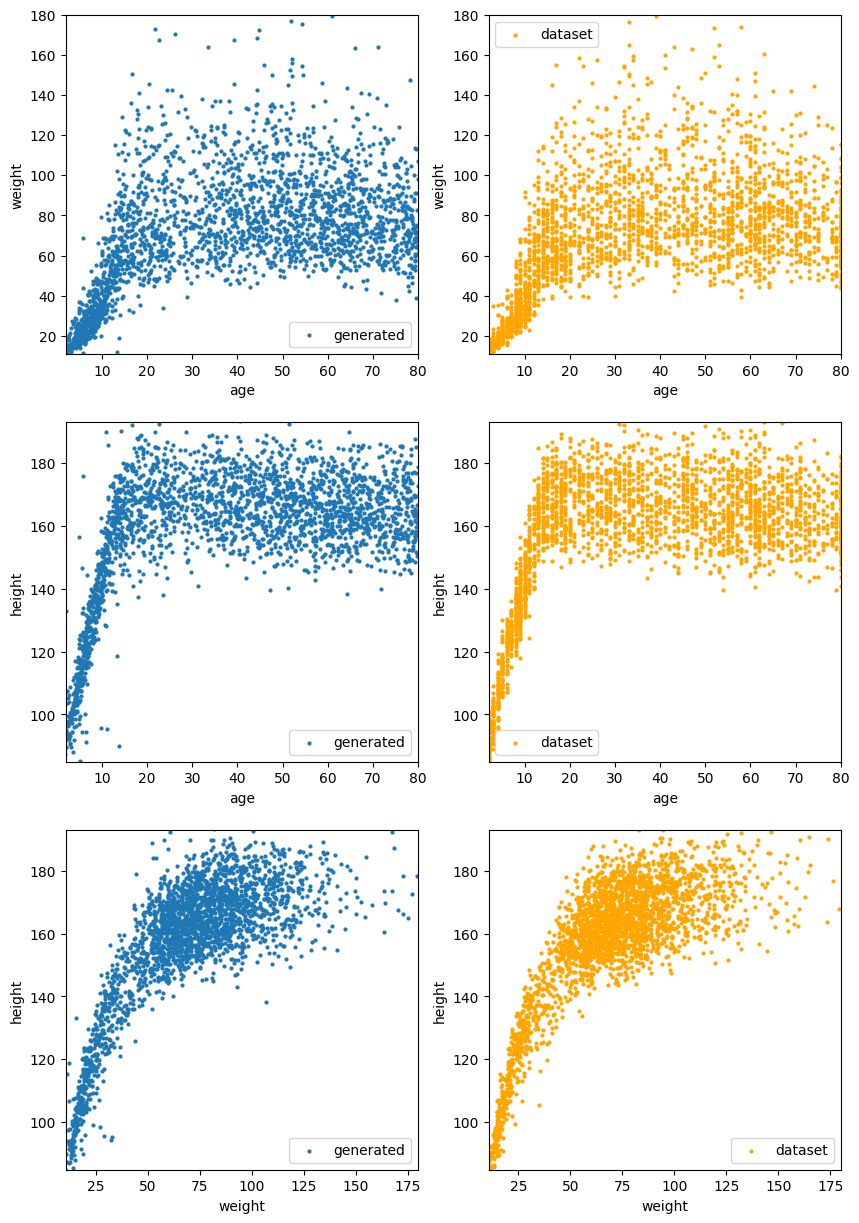

In [130]:
from matplotlib import pyplot as plt
import numpy as np
from kemsekov_torch.common_modules import mmd_rbf

cols = data_csv.columns

n=2500
data_sample = data_csv.sample(n=n).to_numpy()
cond = data[[50]]

with torch.no_grad():
    random_sample = fm_reflow.sample(n).cpu()
    
model_sample=(random_sample*data_std+data_mean)

permutations = [
    [0,1],
    [0,2],
    [1,2]
]

plt.figure(figsize=(10,15))
for i,(indA,indB) in enumerate(permutations):
    X,Y=data_sample[:,indA],data_sample[:,indB]
    X_lim = np.quantile(X,0.001),np.quantile(X,0.999)
    Y_lim = np.quantile(Y,0.001),np.quantile(Y,0.999)
    plt.subplot(3,2,2*i+1)
    plt.scatter(model_sample[:,indA],model_sample[:,indB],s=4,label="generated")
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
    plt.subplot(3,2,2*i+2)
    plt.scatter(X,Y,s=4,label="dataset",c='orange')
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
distrib_distance = mmd_rbf(data_sample,model_sample)[0]
print(f"MMD^2 {distrib_distance:0.4f}")

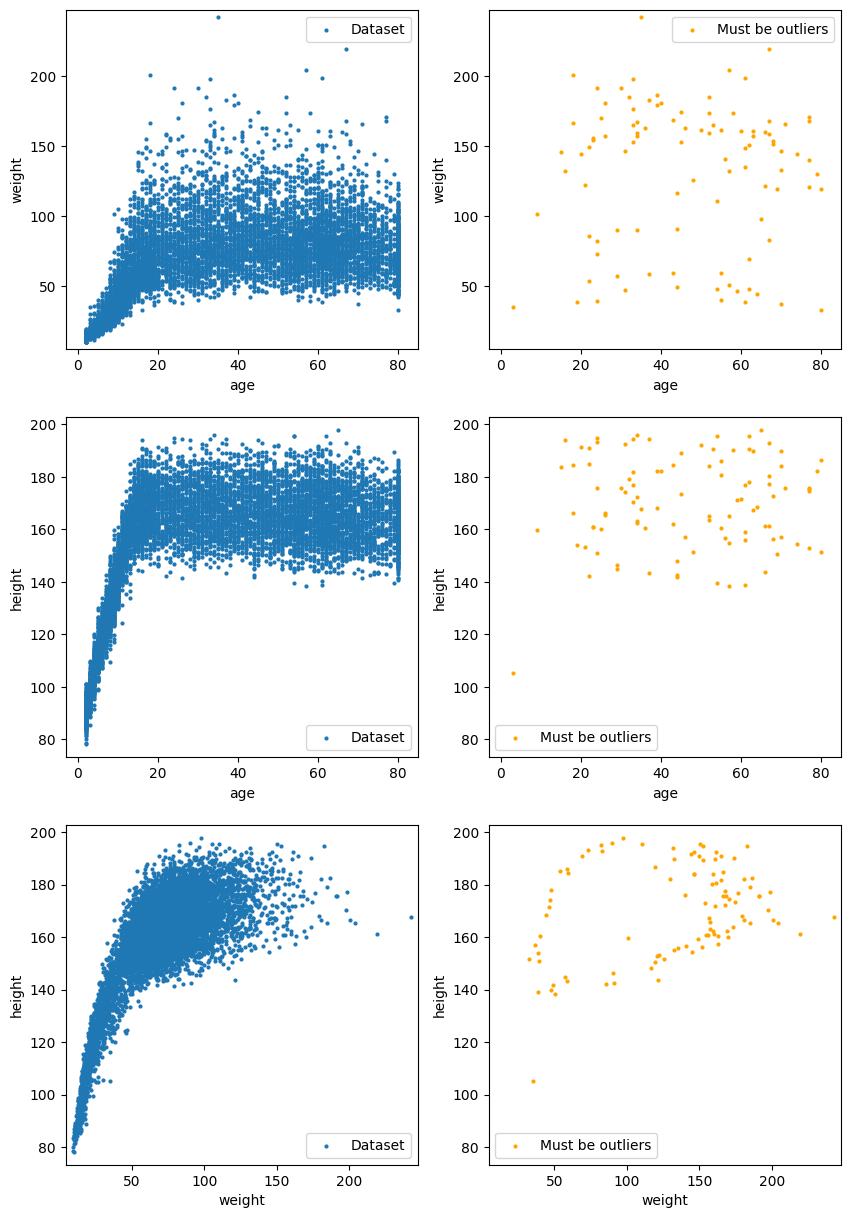

In [131]:
from torch.distributions import Normal
with torch.no_grad():
    probs = fm_reflow.log_prob(data).exp().argsort().cpu()

mask = probs[:100]
data_numpy = data_csv.to_numpy()

plt.figure(figsize=(10,15))
for i,(indA,indB) in enumerate(permutations):
    X,Y=data_numpy[:,indA],data_numpy[:,indB]
    X_lim = np.quantile(X,0)-5,np.quantile(X,1)+5
    Y_lim = np.quantile(Y,0)-5,np.quantile(Y,1)+5
    plt.subplot(3,2,2*i+1)
    plt.scatter(X,Y,s=4,label="Dataset")
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
    plt.subplot(3,2,2*i+2)
    plt.scatter(X[mask],Y[mask],s=4,label="Must be outliers",c='orange')
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()

In [132]:
# list of outliers
data_csv.iloc[probs[:10]]

,age,weight,height
7848,67,219.6,161.3
3671,35,242.6,167.8
365,57,204.4,165.3
5535,18,200.9,166.4
3453,77,170.8,174.7
2636,61,198.7,177.1
7186,77,168.3,175.5
4895,37,183.0,194.6
306,66,121.2,143.7
3504,19,38.6,153.9


Text(0.5, 1.0, 'Weight/height learned Probability visualization')

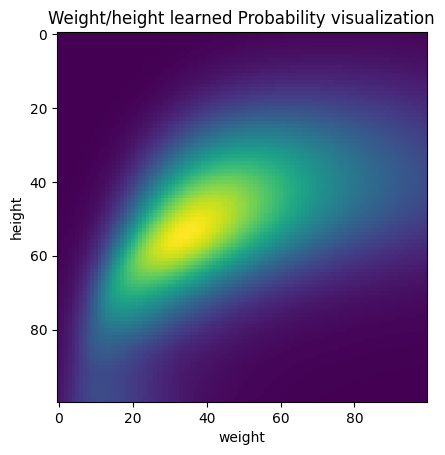

In [133]:
X = torch.linspace(-2.5,2.5,8)
Y = torch.linspace(-2,2.5,100)
Z = torch.linspace(2.5,-2.5,100)

grid = torch.stack(torch.meshgrid([X,Y,Z],indexing="ij"),-1)
with torch.no_grad():
    probs = fm_reflow.log_prob(grid.view(-1,3),random_directions=3).view(grid.shape[:-1])
xy_probs = probs.mean(0)
plt.imshow((xy_probs.T/3).exp())
plt.xlabel("weight")
plt.ylabel("height")
plt.title("Weight/height learned Probability visualization")

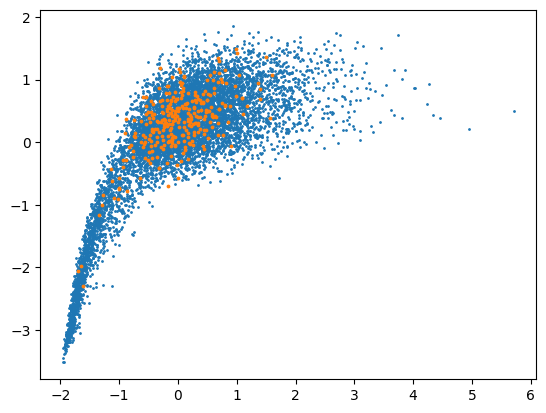

In [134]:
def constraint(x):
    a = ((x[:,1])**2).mean()
    b = ((x[:,2])**2).mean()
    return a+b

constrained_samples = fm_reflow.conditional_sample(
    constraint=constraint,
    num_samples=300,
    noise_scale=0.4,
    steps=2,
    mode_closeness_weight=1
)[:,:3].cpu()

plt.scatter(data[:,1],data[:,2],s=1)
plt.scatter(constrained_samples[:,1],constrained_samples[:,2],s=3)

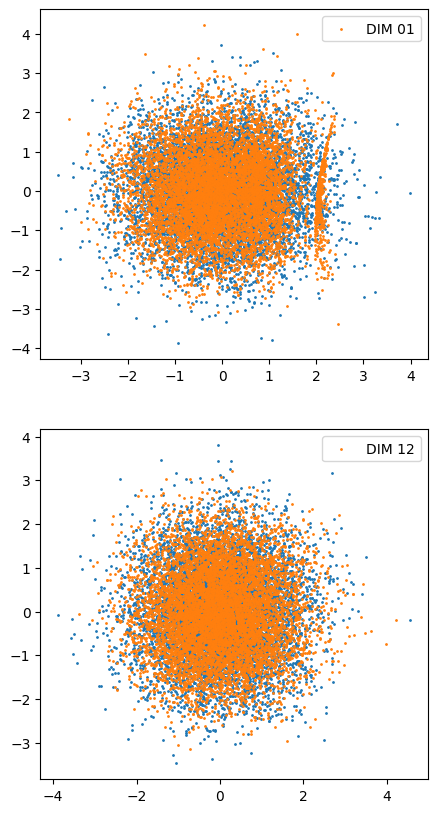

In [135]:
with torch.no_grad():
    latent = fm_reflow.to_prior(data)

plt.figure(figsize=(5,10))
plt.subplot(2,1,1)
plt.scatter(*torch.randn_like(latent)[:,:2].chunk(2,-1),s=1)
plt.scatter(latent[:,0],latent[:,1],s=1,label="DIM 01")
plt.legend()
plt.subplot(2,1,2)
plt.scatter(*torch.randn_like(latent)[:,:2].chunk(2,-1),s=1)
plt.scatter(latent[:,1],latent[:,2],s=1,label="DIM 12")
plt.legend()

In [136]:
ind = torch.randperm(len(data))[:512]
data_opt,loss = fm_reflow.optimize(data[ind],lr=1,epochs=1)
data_opt=data_opt.detach()*data_std+data_mean
loss

tensor(-1014.3068, grad_fn=<NegBackward0>)

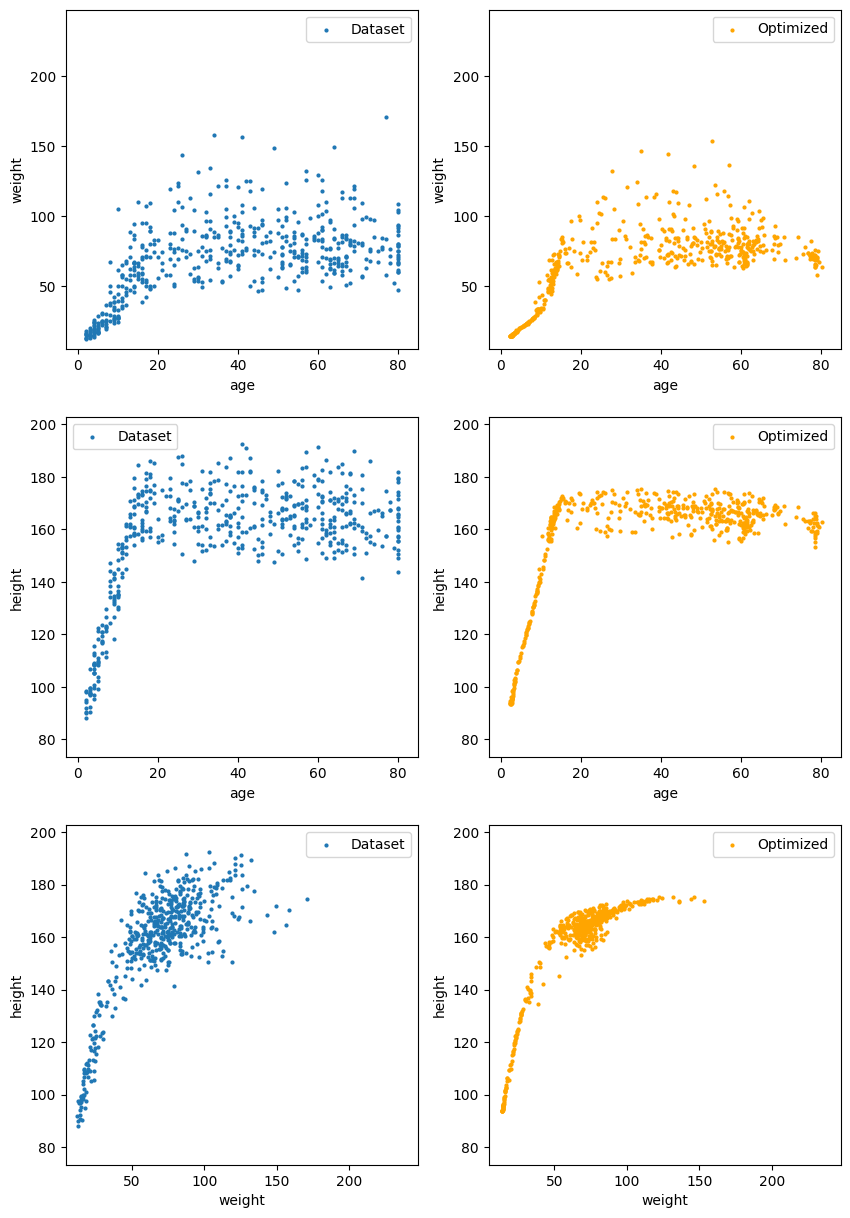

In [137]:

plt.figure(figsize=(10,15))
for i,(indA,indB) in enumerate(permutations):
    X,Y=data_numpy[:,indA],data_numpy[:,indB]
    X_lim = np.quantile(X,0)-5,np.quantile(X,1)+5
    Y_lim = np.quantile(Y,0)-5,np.quantile(Y,1)+5
    plt.subplot(3,2,2*i+1)
    plt.scatter(X[ind],Y[ind],s=4,label="Dataset")
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()
    
    plt.subplot(3,2,2*i+2)
    plt.scatter(data_opt[:,indA],data_opt[:,indB],s=4,label="Optimized",c='orange')
    plt.xlim(*X_lim)
    plt.ylim(*Y_lim)
    plt.xlabel(cols[indA])
    plt.ylabel(cols[indB])
    plt.legend()